In [141]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nelgiriyewithana/global-weather-repository/GlobalWeatherRepository.csv
/kaggle/input/datasets/nelgiriyewithana/global-weather-repository/state.db


In [142]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nelgiriyewithana/global-weather-repository/GlobalWeatherRepository.csv')

# Display first rows
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [143]:
# Check missing values
print(df.isnull().sum())

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [144]:
import matplotlib.pyplot as plt

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print(df.columns)

# Summary statistics
df.describe()

Dataset Shape: (142483, 41)
Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')


,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,142483.000000,142483.000000,1.424830e+05,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,...,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000
mean,19.218345,21.934181,1.747559e+09,21.240040,70.233860,7.985121,12.854519,168.950275,1014.030284,29.943713,...,18.188361,450.658246,57.617471,14.824808,10.133089,23.868970,47.793519,1.687422,2.578560,49.616095
std,24.412247,65.782465,1.830350e+07,9.636271,17.345161,7.123575,11.460969,103.668199,10.184754,0.300698,...,13.685138,744.476229,30.440788,23.352369,34.835949,36.289734,147.393535,0.934153,2.424543,35.116952
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731747e+09,15.500000,59.900000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.200000,196.100000,38.000000,1.750000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747558e+09,23.700000,74.700000,6.700000,10.800000,161.000000,1013.000000,29.930000,...,15.300000,287.850000,55.000000,5.735000,2.405000,13.950000,19.610000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.763364e+09,28.000000,82.300000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,451.850000,73.000000,17.050000,8.140000,27.380000,40.885000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.779259e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [145]:
# Remove duplicates
df.drop_duplicates(inplace=True)

print("Remaining rows:", len(df))

num_cols = df.select_dtypes(include=np.number).columns
columns_to_drop = [
    'temperature_fahrenheit',
    'feels_like_fahrenheit',
    'wind_mph',
    'visibility_miles',
    'precip_in',
    'pressure_in',
    'gust_mph'
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.columns)

Remaining rows: 142483
Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'condition_text', 'wind_kph', 'wind_degree', 'wind_direction',
       'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'feels_like_celsius',
       'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')


In [146]:
# Final dataset information
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142483 entries, 0 to 142482
Data columns (total 34 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       142483 non-null  object 
 1   location_name                 142483 non-null  object 
 2   latitude                      142483 non-null  float64
 3   longitude                     142483 non-null  float64
 4   timezone                      142483 non-null  object 
 5   last_updated_epoch            142483 non-null  int64  
 6   last_updated                  142483 non-null  object 
 7   temperature_celsius           142483 non-null  float64
 8   condition_text                142483 non-null  object 
 9   wind_kph                      142483 non-null  float64
 10  wind_degree                   142483 non-null  int64  
 11  wind_direction                142483 non-null  object 
 12  pressure_mb                   142483 non-nul

,latitude,longitude,last_updated_epoch,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,142483.000000,142483.000000,1.424830e+05,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,...,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000,142483.000000
mean,19.218345,21.934181,1.747559e+09,21.240040,12.854519,168.950275,1014.030284,0.132931,66.763796,39.818652,...,18.188361,450.658246,57.617471,14.824808,10.133089,23.868970,47.793519,1.687422,2.578560,49.616095
std,24.412247,65.782465,1.830350e+07,9.636271,11.460969,103.668199,10.184754,0.555405,23.790871,34.073808,...,13.685138,744.476229,30.440788,23.352369,34.835949,36.289734,147.393535,0.934153,2.424543,35.116952
min,-41.300000,-175.200000,1.715849e+09,-29.800000,3.600000,1.000000,947.000000,0.000000,2.000000,0.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731747e+09,15.500000,6.100000,80.000000,1010.000000,0.000000,51.000000,0.000000,...,10.200000,196.100000,38.000000,1.750000,1.110000,7.030000,9.805000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.747558e+09,23.700000,10.800000,161.000000,1013.000000,0.000000,72.000000,29.000000,...,15.300000,287.850000,55.000000,5.735000,2.405000,13.950000,19.610000,1.000000,2.000000,49.000000
75%,40.400000,49.882200,1.763364e+09,28.000000,17.600000,256.000000,1018.000000,0.020000,86.000000,75.000000,...,24.100000,451.850000,73.000000,17.050000,8.140000,27.380000,40.885000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.779259e+09,79.300000,2963.200000,360.000000,3006.000000,42.240000,100.000000,100.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


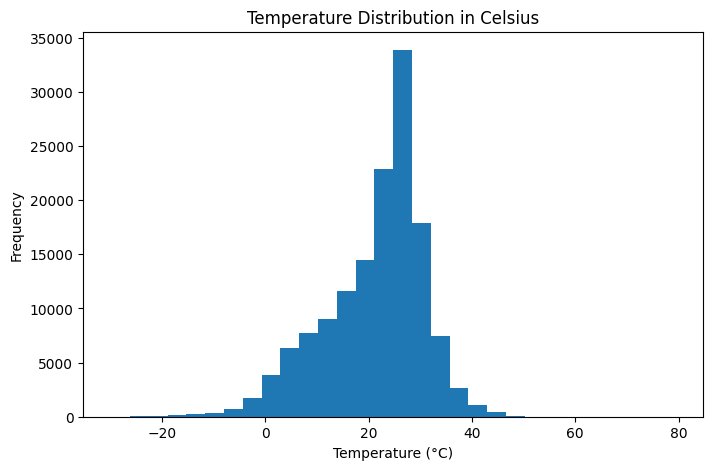

In [147]:
# Histogram of Temperature in Celsius
plt.figure(figsize=(8,5))

plt.hist(df['temperature_celsius'], bins=30)

plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution in Celsius')

plt.show()

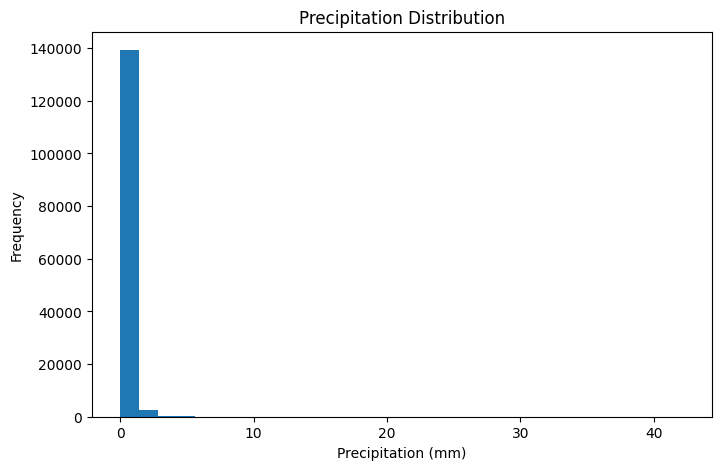

In [148]:

plt.figure(figsize=(8,5))

plt.hist(df['precip_mm'], bins=30)

plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.title('Precipitation Distribution')

plt.show()

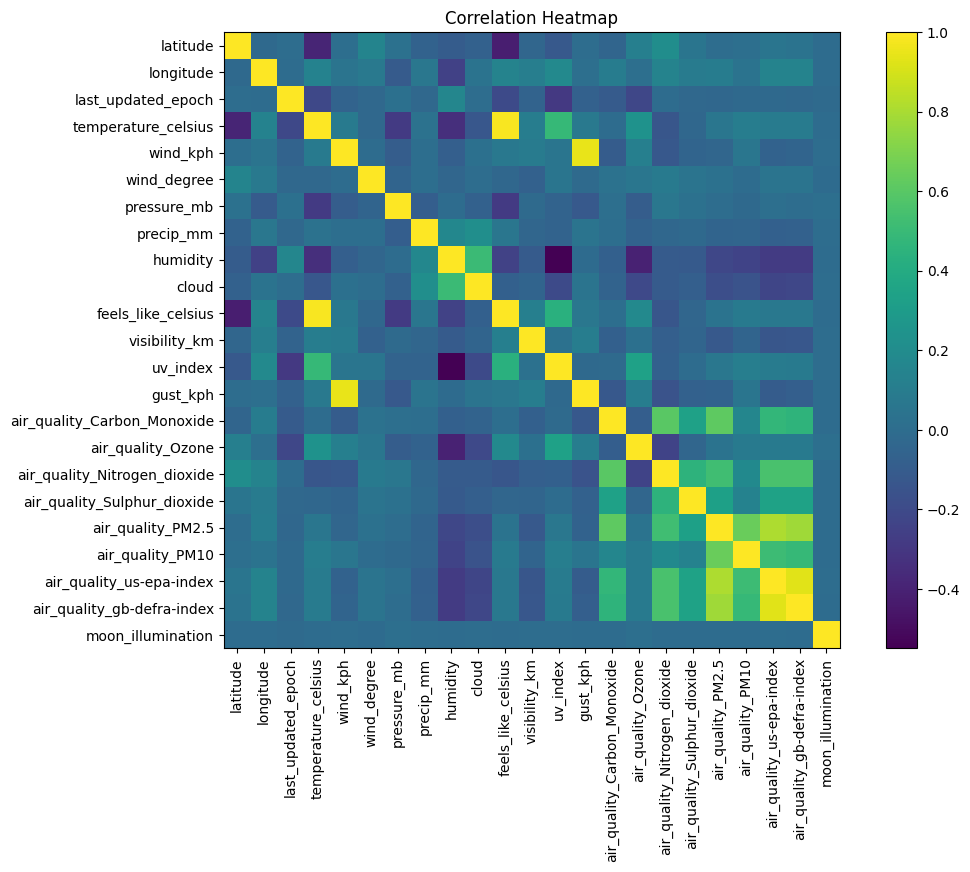

In [149]:
plt.figure(figsize=(12,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.title('Correlation Heatmap')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.show()

In [150]:
# Time-Series Forecasting

# Convert to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Sort by time
df = df.sort_values('last_updated')

In [151]:
# Set datetime as index
df.set_index('last_updated', inplace=True)

temperature_series = df['temperature_celsius']

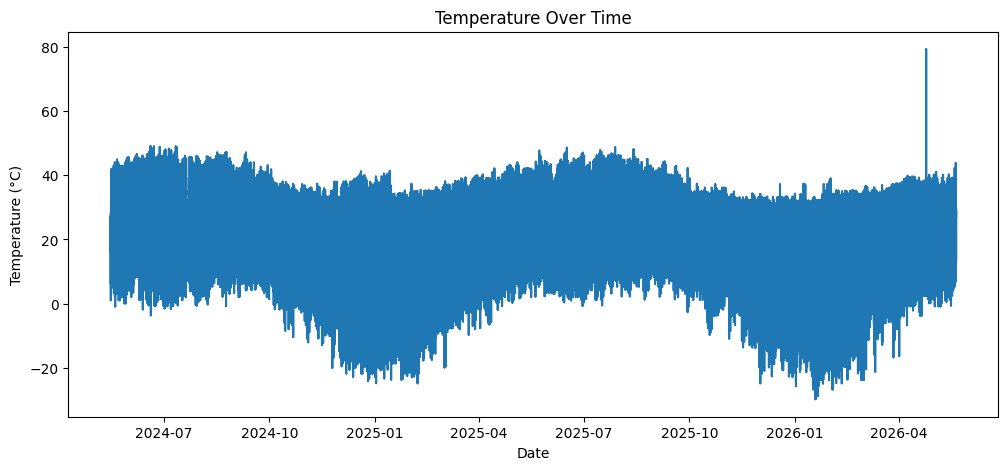

In [152]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(temperature_series)

plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')

plt.show()

In [153]:
train_size = int(len(temperature_series) * 0.7)

train = temperature_series[:train_size]
test = temperature_series[train_size:]

In [154]:
# Moving Average Forecast Model

window = 5

maf_predictions = test.rolling(window=window).mean()
maf_predictions = maf_predictions.dropna()
test = test[len(test) - len(maf_predictions):]

In [155]:
# Performance evaluation of Moving Average Forecast Model
from sklearn.metrics import mean_absolute_error, mean_squared_error

maf_mae = mean_absolute_error(test, maf_predictions)
maf_mse = mean_squared_error(test, maf_predictions)
maf_rmse = np.sqrt(maf_mse)

print("MAE:", maf_mae)
print("MSE:", maf_mse)
print("RMSE:", maf_rmse)

MAE: 6.263974637935472
MSE: 66.87623624154794
RMSE: 8.177789202562508


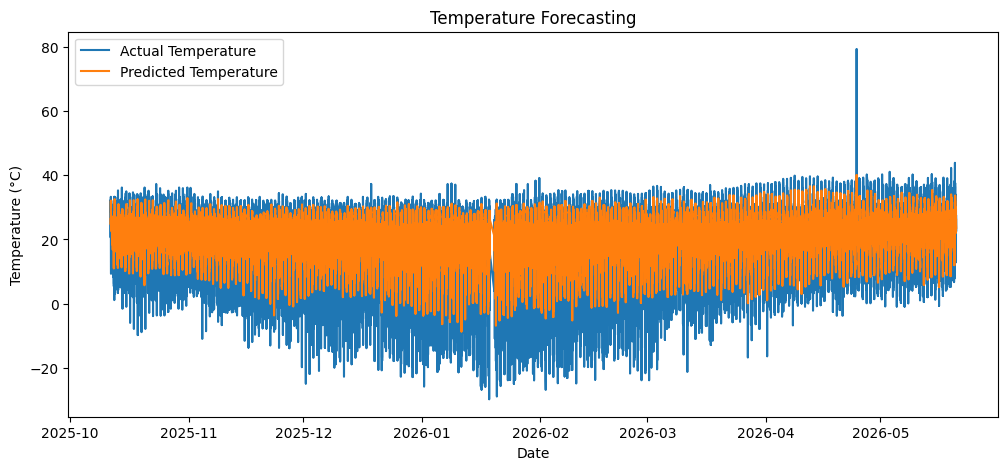

In [156]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label='Actual Temperature')
plt.plot(maf_predictions.index, maf_predictions, label='Predicted Temperature')

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Forecasting')

plt.legend()

plt.show()

In [157]:
# Advanced Assessment

# Anomaly Detection with IQR
temperature = df['temperature_celsius']

Q1 = temperature.quantile(0.25)
Q3 = temperature.quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 15.5
Q3: 28.0
IQR: 12.5
Lower Bound: -3.25
Upper Bound: 46.75


In [158]:
# Detect anomalies (IQR)
anomalies = df[
    (df['temperature_celsius'] < lower_bound) |
    (df['temperature_celsius'] > upper_bound)
]

print("Number of anomalies:", len(anomalies))

Number of anomalies: 1975


In [159]:
anomalies[['country',
           'location_name',
           'temperature_celsius']].head()



,country,location_name,temperature_celsius
last_updated,,,
2024-06-18 17:00:00,Iraq,Baghdad,47.4
2024-06-19 16:45:00,Iraq,Baghdad,47.8
2024-06-19 16:45:00,Kuwait,Kuwait City,49.2
2024-06-19 23:45:00,Australia,Canberra,-3.7
2024-06-20 16:45:00,Iraq,Baghdad,47.9


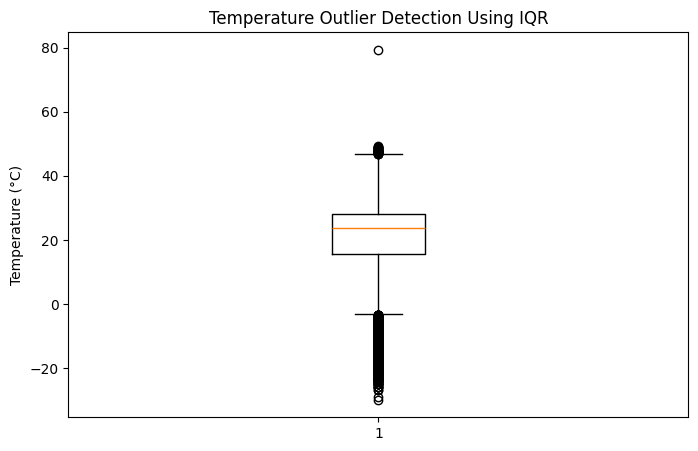

In [160]:
plt.figure(figsize=(8,5))

plt.boxplot(df['temperature_celsius'])

plt.title('Temperature Outlier Detection Using IQR')
plt.ylabel('Temperature (°C)')

plt.show()

In [161]:
# Anomaly detection with zscore

from scipy.stats import zscore

# Compute Z-scores
df['temperature_zscore'] = zscore(df['temperature_celsius'])

# Display first rows
df[['temperature_celsius', 'temperature_zscore']].head()

,temperature_celsius,temperature_zscore
last_updated,,
2024-05-16 01:45:00,16.1,-0.533407
2024-05-16 02:45:00,23.0,0.182640
2024-05-16 02:45:00,26.0,0.493965
2024-05-16 02:45:00,20.0,-0.128685
2024-05-16 02:45:00,26.0,0.493965


In [162]:
# Detect anomalies
anomalies = df[np.abs(df['temperature_zscore']) > 3]

print("Number of anomalies:", len(anomalies))

anomalies[['country',
           'location_name',
           'temperature_celsius',
           'temperature_zscore']].head()

Number of anomalies: 961


,country,location_name,temperature_celsius,temperature_zscore
last_updated,,,,
2024-10-14 17:30:00,Mongolia,Ulaanbaatar,-8.4,-3.075894
2024-10-17 17:30:00,Mongolia,Ulaanbaatar,-7.9,-3.024006
2024-10-21 17:15:00,Mongolia,Ulaanbaatar,-10.4,-3.283443
2024-11-02 17:15:00,Mongolia,Ulaanbaatar,-11.0,-3.345708
2024-11-03 17:00:00,Mongolia,Ulaanbaatar,-12.1,-3.459861


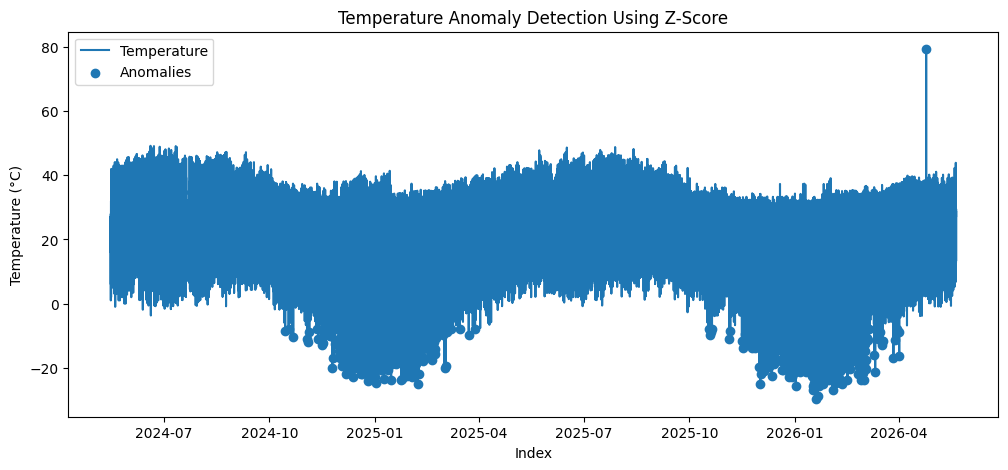

In [163]:
plt.figure(figsize=(12,5))

# Plot all temperatures
plt.plot(df.index,
         df['temperature_celsius'],
         label='Temperature')

# Highlight anomalies
plt.scatter(anomalies.index,
            anomalies['temperature_celsius'],
            label='Anomalies')

plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Anomaly Detection Using Z-Score')

plt.legend()

plt.show()

In [164]:
# Naive Forecast Model (baseline)
naive_predictions = test.shift(1)

# Remove missing value
naive_predictions = naive_predictions.dropna()

aligned_test_naive = test[1:]

naive_mae = mean_absolute_error(aligned_test_naive, naive_predictions)

naive_rmse = np.sqrt(
    mean_squared_error(aligned_test_naive, naive_predictions)
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 9.3012634534394
Naive RMSE: 12.77686621390438


In [165]:
# ARIMA Forecast Model
from statsmodels.tsa.arima.model import ARIMA

# Build model
arima_model = ARIMA(train, order=(5,1,0))

# Train model
arima_model_fit = arima_model.fit()

# Forecast
arima_predictions = arima_model_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test, arima_predictions)

arima_rmse = np.sqrt(
    mean_squared_error(test, arima_predictions)
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

ARIMA MAE: 8.425267608662677
ARIMA RMSE: 10.545407883271404


In [166]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Build model
exp_model = ExponentialSmoothing(train)

# Train model
exp_fit = exp_model.fit()

# Forecast
exp_predictions = exp_fit.forecast(len(test))

exp_mae = mean_absolute_error(test, exp_predictions)

exp_rmse = np.sqrt(
    mean_squared_error(test, exp_predictions)
)

print("Exponential Smoothing MAE:", exp_mae)
print("Exponential Smoothing RMSE:", exp_rmse)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Exponential Smoothing MAE: 8.527812271765029
Exponential Smoothing RMSE: 11.362021421347873


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [167]:
results = pd.DataFrame({
    'Model': ['Naive',
              'Moving Average',
              'ARIMA',
              'Exponential Smoothing'],
    
    'MAE': [naive_mae,
            maf_mae,
            arima_mae,
            exp_mae],
    
    'RMSE': [naive_rmse,
             maf_rmse,
             arima_rmse,
             exp_rmse]
})

print(results)

                   Model       MAE       RMSE
0                  Naive  9.301263  12.776866
1         Moving Average  6.263975   8.177789
2                  ARIMA  8.425268  10.545408
3  Exponential Smoothing  8.527812  11.362021


In [168]:
# Ensemble Model
# Ensemble prediction (simple average)
ensemble_predictions = (
    arima_predictions + exp_predictions
) / 2

In [169]:
ensemble_mae = mean_absolute_error(
    test,
    ensemble_predictions
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        test,
        ensemble_predictions
    )
)

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)

Ensemble MAE: 8.407270766763755
Ensemble RMSE: 10.868797135374253


In [170]:
results = pd.DataFrame({
    'Model': ['Naive',
              'Moving Average',
              'ARIMA',
              'Exponential Smoothing',
              'Ensemble'],
    
    'MAE': [naive_mae,
            maf_mae,
            arima_mae,
            exp_mae,
            ensemble_mae],
    
    'RMSE': [naive_rmse,
             maf_rmse,
             arima_rmse,
             exp_rmse,
             ensemble_rmse]
})

print(results)

                   Model       MAE       RMSE
0                  Naive  9.301263  12.776866
1         Moving Average  6.263975   8.177789
2                  ARIMA  8.425268  10.545408
3  Exponential Smoothing  8.527812  11.362021
4               Ensemble  8.407271  10.868797


In [171]:
# Convert predictions to plain arrays
maf_arr = np.asarray(maf_predictions)
arima_arr = np.asarray(arima_predictions)
exp_arr = np.asarray(exp_predictions)

# Use the shortest length because moving average may have fewer values
min_len = min(len(maf_arr), len(arima_arr), len(exp_arr), len(test))

maf_arr = maf_arr[-min_len:]
arima_arr = arima_arr[-min_len:]
exp_arr = exp_arr[-min_len:]
test_arr = np.asarray(test)[-min_len:]

# Simple ensemble
ensemble_all = (maf_arr + arima_arr + exp_arr) / 3

In [172]:
ensemble_all_mae = mean_absolute_error(test_arr, ensemble_all)

ensemble_all_rmse = np.sqrt(
    mean_squared_error(test_arr, ensemble_all)
)

print("All-model Ensemble MAE:", ensemble_all_mae)
print("All-model Ensemble RMSE:", ensemble_all_rmse)

All-model Ensemble MAE: 7.406133946647048
All-model Ensemble RMSE: 9.460453538603453


In [173]:
weighted_ensemble = (
    0.6 * maf_arr +
    0.2 * arima_arr +
    0.2 * exp_arr
)

weighted_mae = mean_absolute_error(test_arr, weighted_ensemble)

weighted_rmse = np.sqrt(
    mean_squared_error(test_arr, weighted_ensemble)
)

print("Weighted Ensemble MAE:", weighted_mae)
print("Weighted Ensemble RMSE:", weighted_rmse)

Weighted Ensemble MAE: 6.77130660819147
Weighted Ensemble RMSE: 8.654978450126713


country
Saudi Arabien           45.000000
Marrocos                40.300000
Turkménistan            37.800000
Турция                  34.000000
United Arab Emirates    32.125683
Qatar                   32.120137
Cambodia                31.862927
Oman                    31.561885
Djibouti                31.292466
Inde                    31.200000
Name: temperature_celsius, dtype: float64


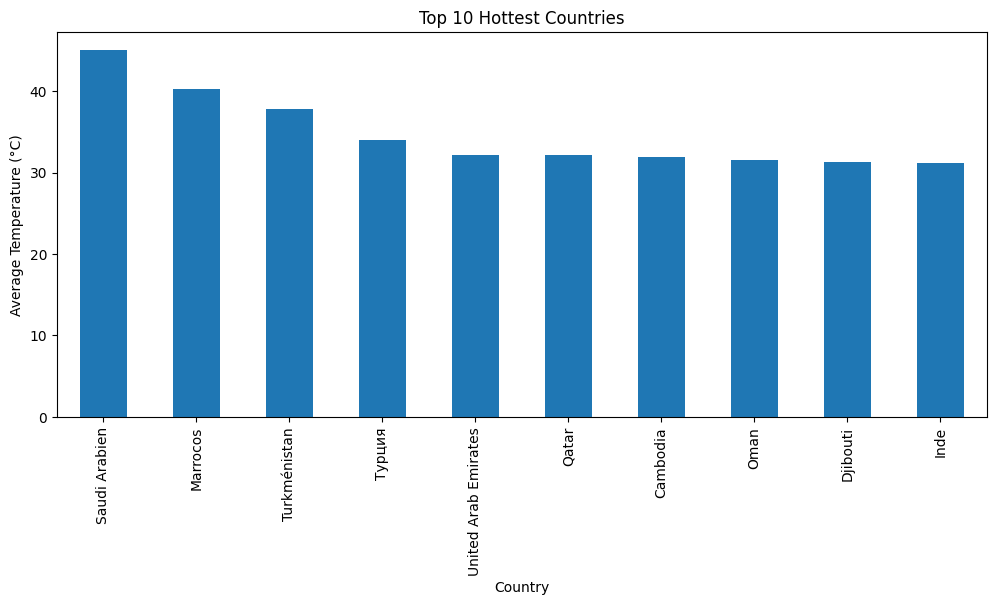

In [174]:
# Unique Analyses

# Average Temperature by Country
avg_temp_country = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
)

print(avg_temp_country.head(10))

plt.figure(figsize=(12,5))

avg_temp_country.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')
plt.title('Top 10 Hottest Countries')

plt.show()

country
Lao People's Democratic Republic    1.970000
Letonia                             1.830000
Malásia                             1.550000
Malaysia                            0.586156
USA United States of America        0.530000
Brunei Darussalam                   0.492014
Papua New Guinea                    0.490451
Indonesia                           0.482314
Sierra Leone                        0.457805
Guyana                              0.449986
Name: precip_mm, dtype: float64


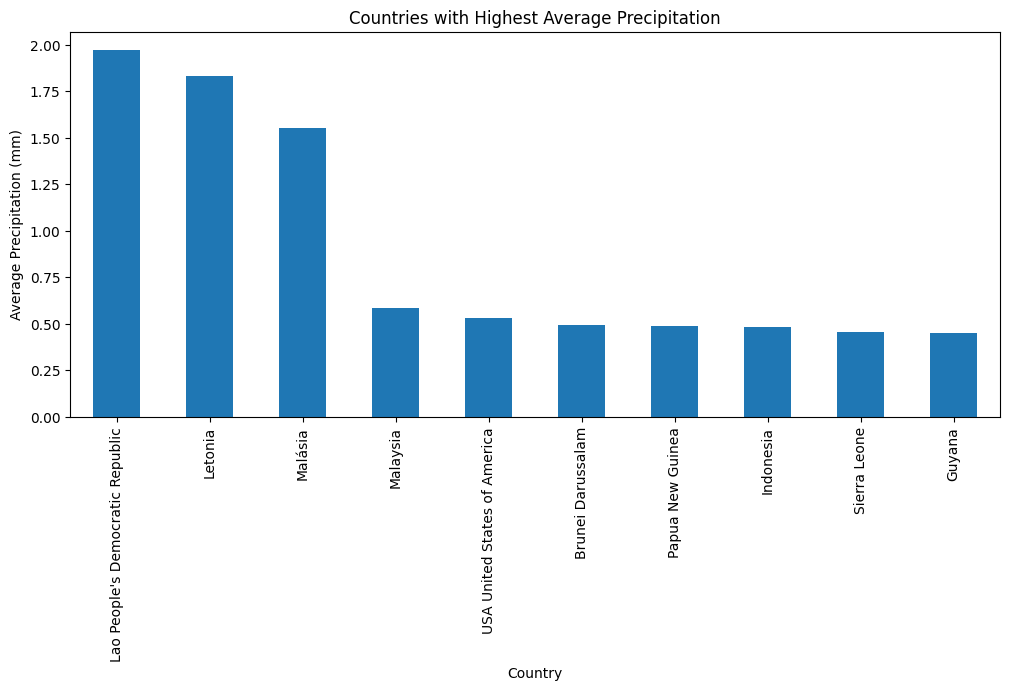

In [175]:
# Average Precipitation by Country
avg_precip = (
    df.groupby('country')['precip_mm']
    .mean()
    .sort_values(ascending=False)
)

print(avg_precip.head(10))

plt.figure(figsize=(12,5))

avg_precip.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average Precipitation (mm)')
plt.title('Countries with Highest Average Precipitation')

plt.show()

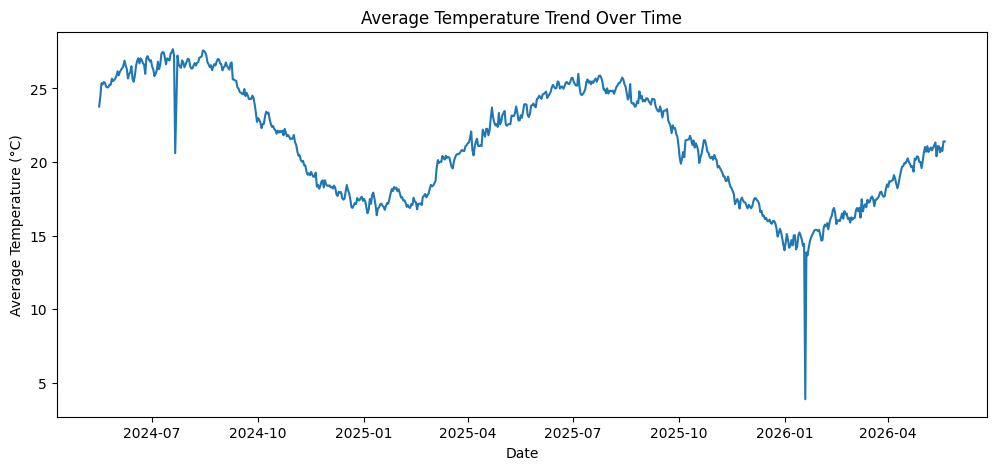

In [176]:
# temperature trend over time
df.index = pd.to_datetime(df.index)

# Sort by datetime index
df = df.sort_index()

# Daily average temperature
daily_temp = (
    df.groupby(df.index.date)['temperature_celsius']
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(daily_temp)

plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Trend Over Time')

plt.show()

In [177]:
df['country'].unique()

array(['United States of America', 'Honduras', 'El Salvador', 'Guatemala',
       'Belize', 'Nicaragua', 'Costa Rica', 'Mexico', 'Jamaica', 'Panama',
       'Ecuador', 'Peru', 'Canada', 'Saint Lucia',
       'Saint Kitts and Nevis', 'Grenada', 'Guyana', 'Brazil',
       'Dominican Republic', 'Haiti', 'Antigua and Barbuda',
       'Saint Vincent and the Grenadines', 'Chile', 'Venezuela',
       'Paraguay', 'Barbados', 'Bahamas', 'Bolivia',
       'Trinidad and Tobago', 'Dominica', 'Cuba', 'Suriname', 'Argentina',
       'Uruguay', 'Cape Verde', 'Ghana', 'Burkina Faso', 'Guinea',
       'Senegal', 'Guinea-Bissau', 'Liberia', 'Mali', 'Sierra Leone',
       'Mauritania', 'Iceland', 'Gambia', 'Congo', 'Benin', 'Nigeria',
       'Portugal', 'Tunisia', 'Gabon', 'United Kingdom',
       'Democratic Republic of Congo', 'Algeria', 'Chad',
       'Central African Republic', 'Niger', 'Ireland',
       'Equatorial Guinea', 'Angola', 'Morocco', 'Cameroon', 'Mozambique',
       'South Africa', 'Sudan

country
Canada                       4.910274
Ghana                       27.317462
United States of America     8.649862
Name: temperature_celsius, dtype: float64


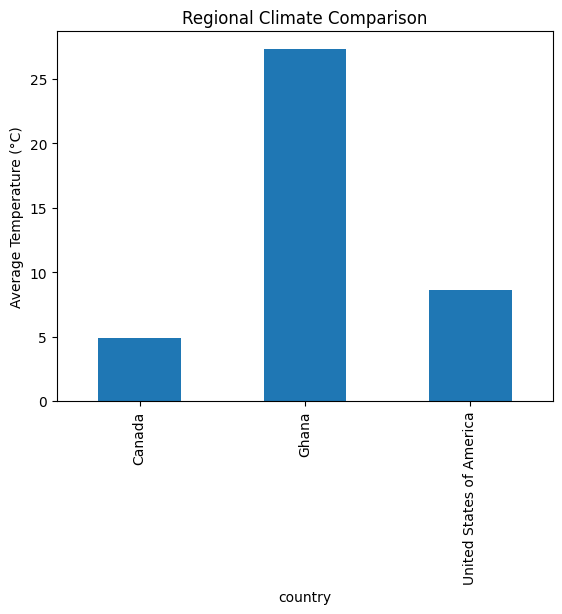

In [178]:
selected = ['Canada', 'Ghana', 'United States of America']

regional_temp = (
    df[df['country'].isin(selected)]
    .groupby('country')['temperature_celsius']
    .mean()
)

print(regional_temp)


regional_temp.plot(kind='bar')

plt.ylabel('Average Temperature (°C)')
plt.title('Regional Climate Comparison')

plt.show()

In [179]:
# Environmental Impact Analysis

environmental_features = [
    'temperature_celsius',
    'humidity',
    'wind_kph',
    'precip_mm',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone'
]

env_df = df[environmental_features]

In [180]:
correlation_matrix = env_df.corr()

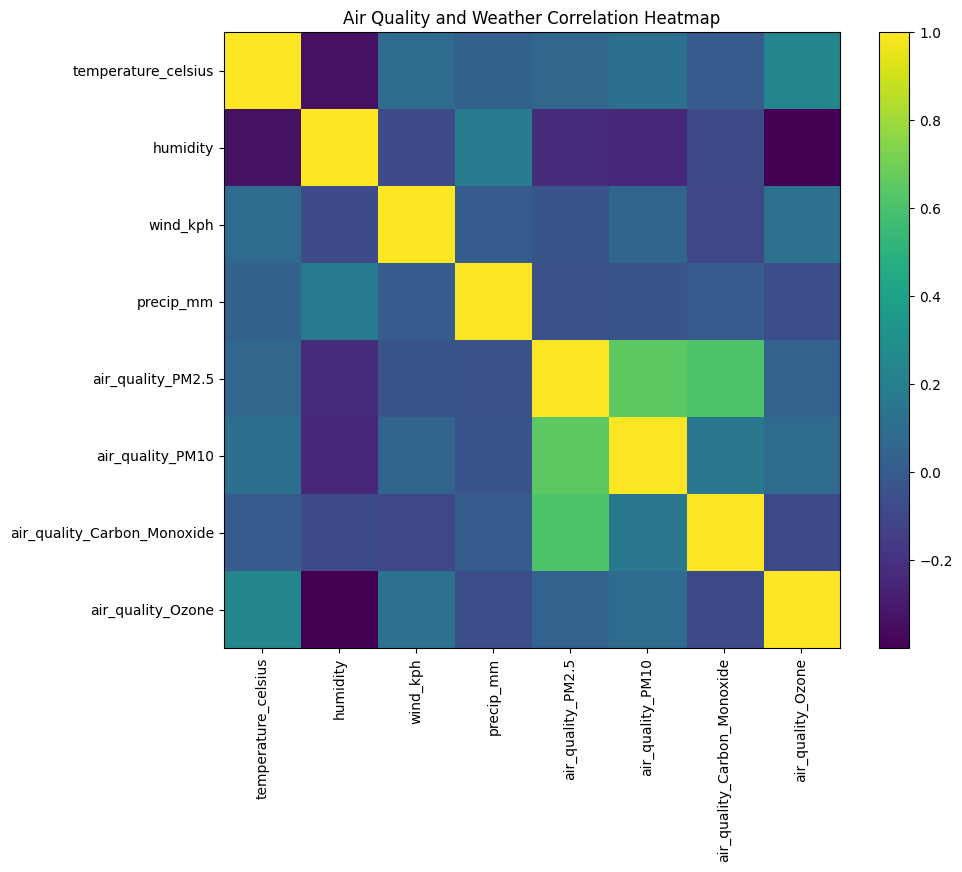

In [181]:
# Correlation matrix
plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Air Quality and Weather Correlation Heatmap')

plt.show()

<Figure size 800x500 with 0 Axes>

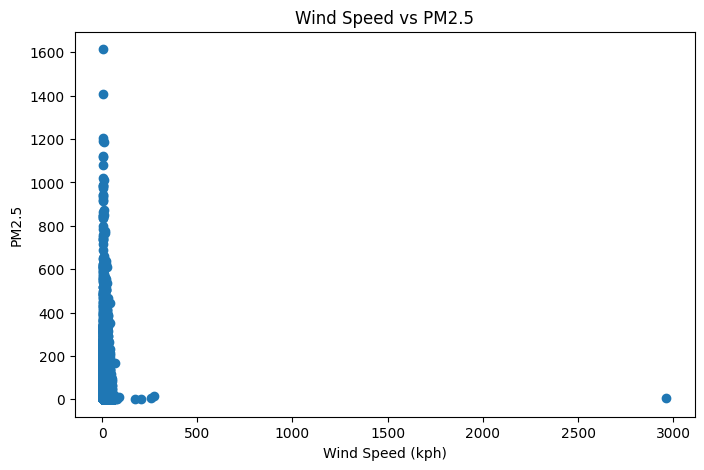

<Figure size 800x500 with 0 Axes>

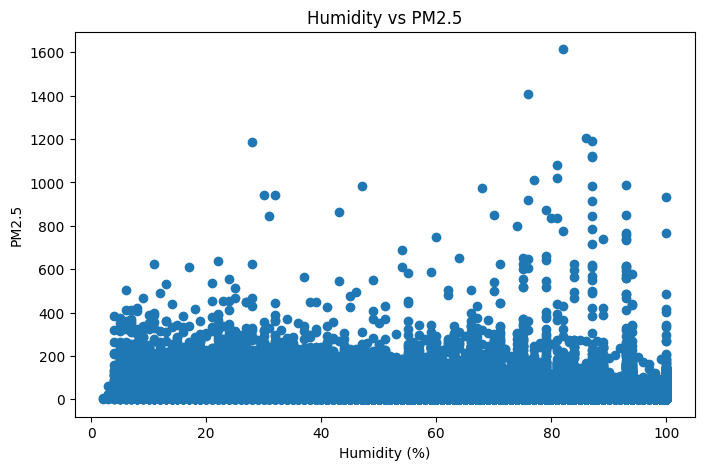

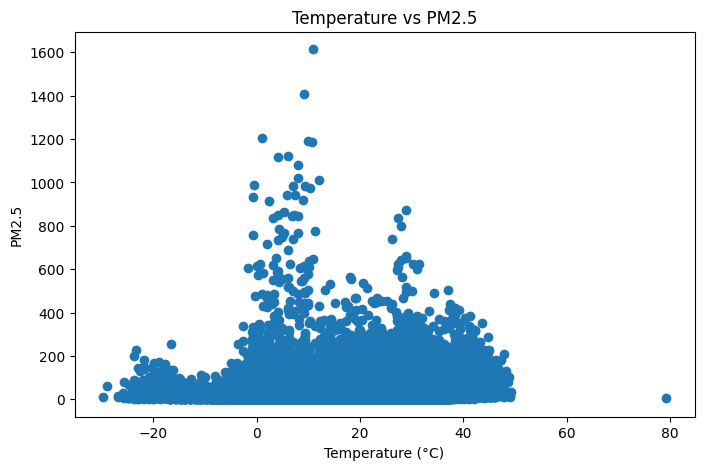

In [182]:
# wind speed vs pm 2.5
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))

plt.scatter(
    df['wind_kph'],
    df['air_quality_PM2.5']
)

plt.xlabel('Wind Speed (kph)')
plt.ylabel('PM2.5')

plt.title('Wind Speed vs PM2.5')

plt.show()

# humidity vs pm 2.5
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))

plt.scatter(
    df['humidity'],
    df['air_quality_PM2.5']
)

plt.xlabel('Humidity (%)')
plt.ylabel('PM2.5')

plt.title('Humidity vs PM2.5')

plt.show()

# temp vs pm 2.5
plt.figure(figsize=(8,5))

plt.scatter(
    df['temperature_celsius'],
    df['air_quality_PM2.5']
)

plt.xlabel('Temperature (°C)')
plt.ylabel('PM2.5')

plt.title('Temperature vs PM2.5')

plt.show()

country
Chile           145.302888
Saudi Arabia    136.883502
China           129.958473
India           110.336692
Kuwait           91.241081
Indonesia        83.706655
Südkorea         70.200000
Bangladesh       69.886409
Mauritania       67.385472
Bahrain          64.140867
Name: air_quality_PM2.5, dtype: float64


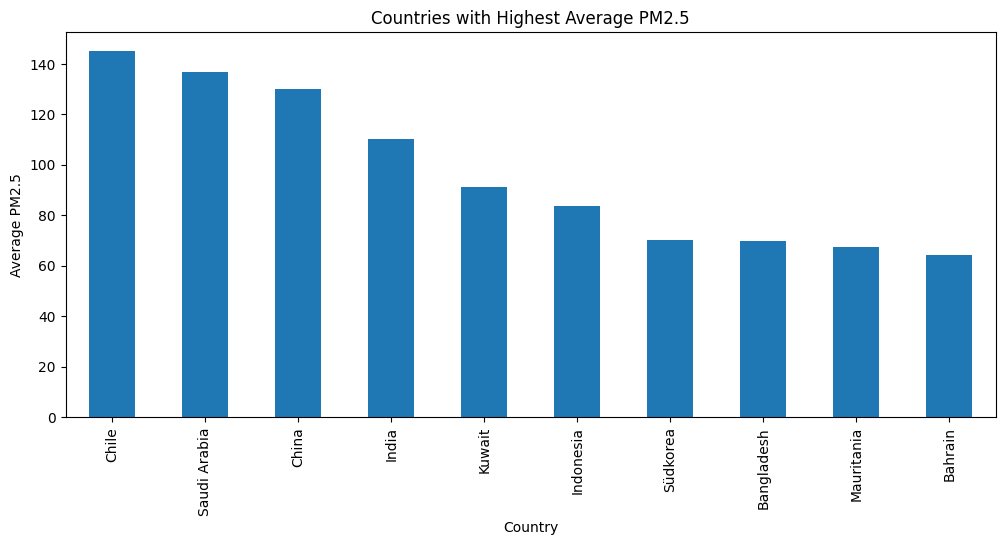

In [183]:
pm25_country = (
    df.groupby('country')['air_quality_PM2.5']
    .mean()
    .sort_values(ascending=False)
)

print(pm25_country.head(10))

plt.figure(figsize=(12,5))

pm25_country.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average PM2.5')

plt.title('Countries with Highest Average PM2.5')

plt.show()

In [184]:
# Features
X = df[[
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'uv_index',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]]

# Target
y = df['temperature_celsius']

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [186]:
from sklearn.ensemble import RandomForestRegressor

# Build model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

             Feature  Importance
5           uv_index    0.564022
2        pressure_mb    0.485226
0           humidity    0.281099
4              cloud    0.116797
7  air_quality_PM2.5    0.080791
8   air_quality_PM10    0.080521
1           wind_kph    0.034094
6      visibility_km    0.033296
3          precip_mm    0.019103


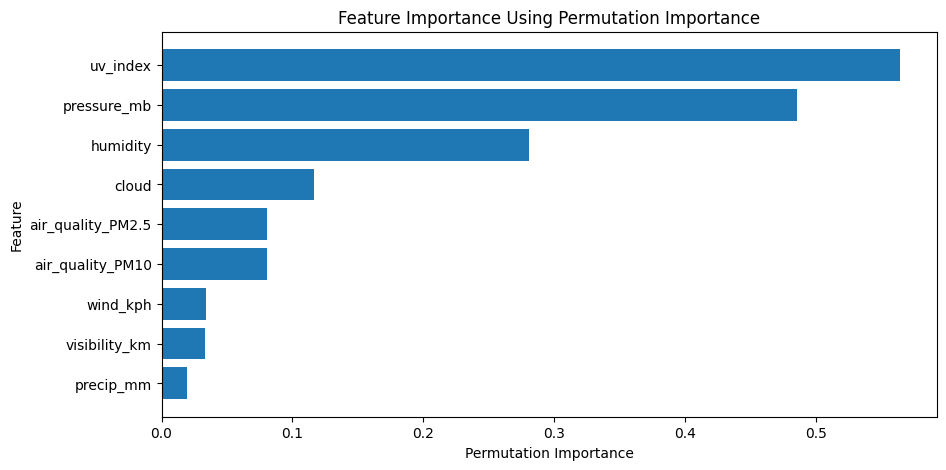

In [187]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Permutation Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Using Permutation Importance')

plt.gca().invert_yaxis()

plt.show()

uv_index             0.489380
air_quality_PM10     0.110114
visibility_km        0.108552
wind_kph             0.091823
air_quality_PM2.5    0.061328
precip_mm            0.034406
cloud               -0.128072
pressure_mb         -0.287770
humidity            -0.339098
dtype: float64


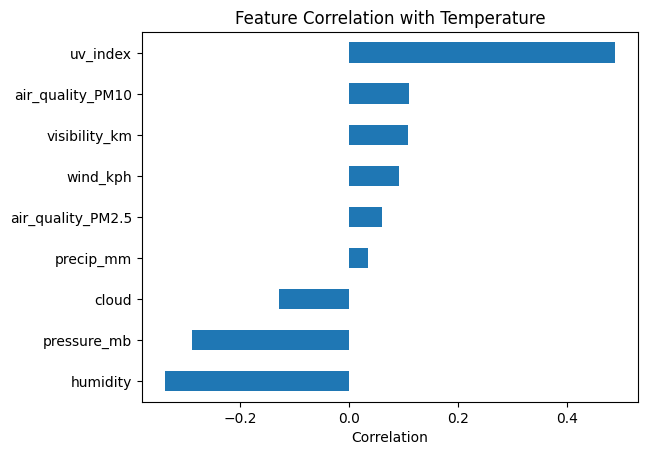

In [188]:
# Correlation based importance
correlations = X.corrwith(y)

print(correlations.sort_values(ascending=False))

correlations.sort_values().plot(kind='barh')

plt.xlabel('Correlation')
plt.title('Feature Correlation with Temperature')

plt.show()

country
Saudi Arabien           45.000000
Marrocos                40.300000
Turkménistan            37.800000
Турция                  34.000000
United Arab Emirates    32.125683
Qatar                   32.120137
Cambodia                31.862927
Oman                    31.561885
Djibouti                31.292466
Inde                    31.200000
Name: temperature_celsius, dtype: float64


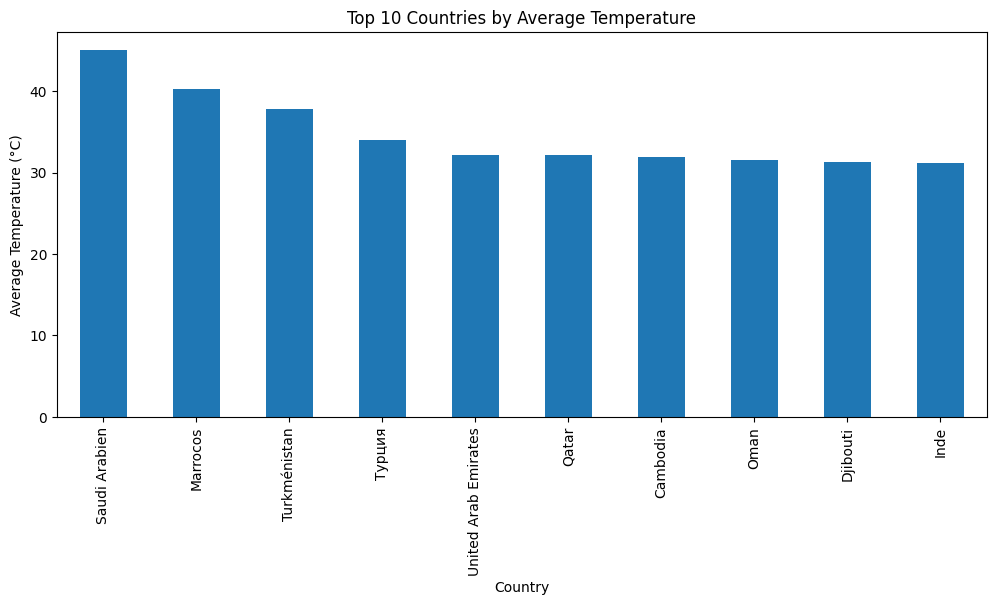

In [189]:
# Geographical Pattern Analysis
country_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
)

print(country_temp.head(10))


plt.figure(figsize=(12,5))

country_temp.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average Temperature (°C)')
plt.title('Top 10 Countries by Average Temperature')

plt.show()

country
Chile           145.302888
Saudi Arabia    136.883502
China           129.958473
India           110.336692
Kuwait           91.241081
Indonesia        83.706655
Südkorea         70.200000
Bangladesh       69.886409
Mauritania       67.385472
Bahrain          64.140867
Name: air_quality_PM2.5, dtype: float64


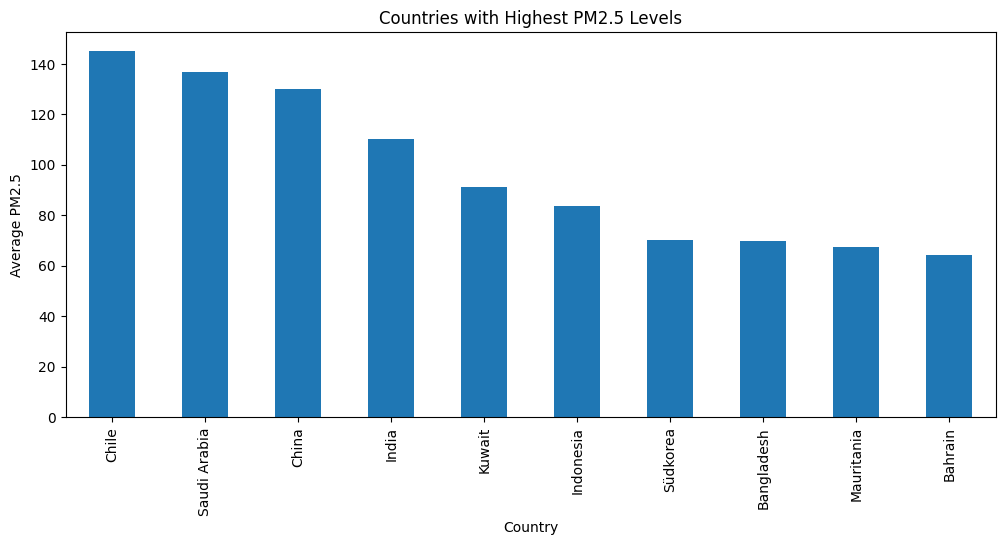

In [190]:
country_pm25 = (
    df.groupby('country')['air_quality_PM2.5']
    .mean()
    .sort_values(ascending=False)
)

print(country_pm25.head(10))

plt.figure(figsize=(12,5))

country_pm25.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average PM2.5')

plt.title('Countries with Highest PM2.5 Levels')

plt.show()

country
Lao People's Democratic Republic    1.970000
Letonia                             1.830000
Malásia                             1.550000
Malaysia                            0.586156
USA United States of America        0.530000
Brunei Darussalam                   0.492014
Papua New Guinea                    0.490451
Indonesia                           0.482314
Sierra Leone                        0.457805
Guyana                              0.449986
Name: precip_mm, dtype: float64


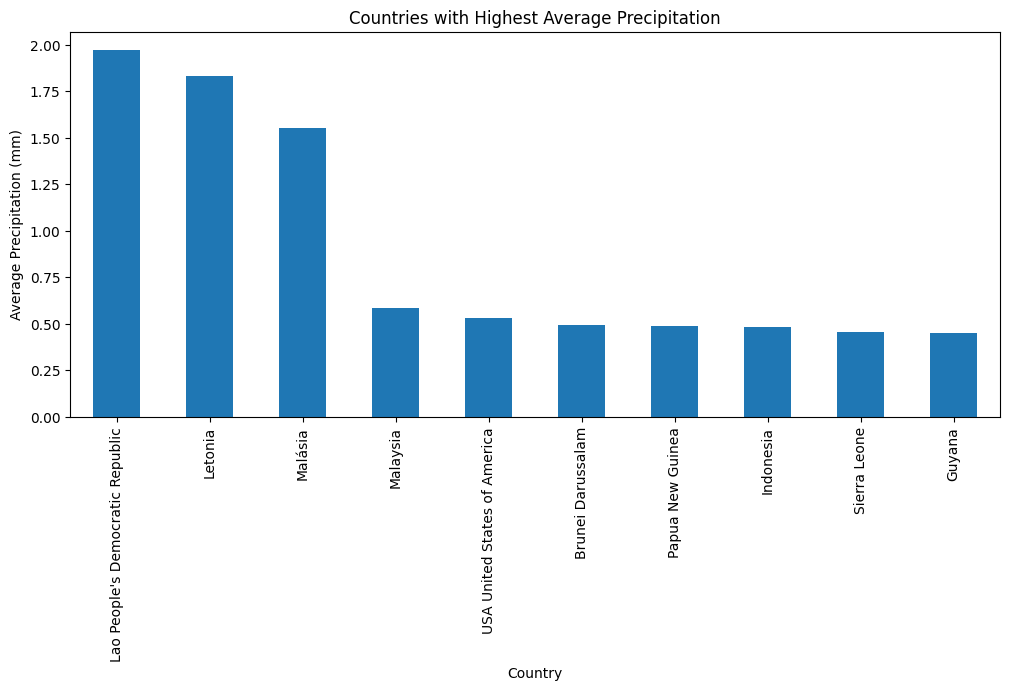

In [191]:
country_precip = (
    df.groupby('country')['precip_mm']
    .mean()
    .sort_values(ascending=False)
)

print(country_precip.head(10))

plt.figure(figsize=(12,5))

country_precip.head(10).plot(kind='bar')

plt.xlabel('Country')
plt.ylabel('Average Precipitation (mm)')
plt.title('Countries with Highest Average Precipitation')

plt.show()

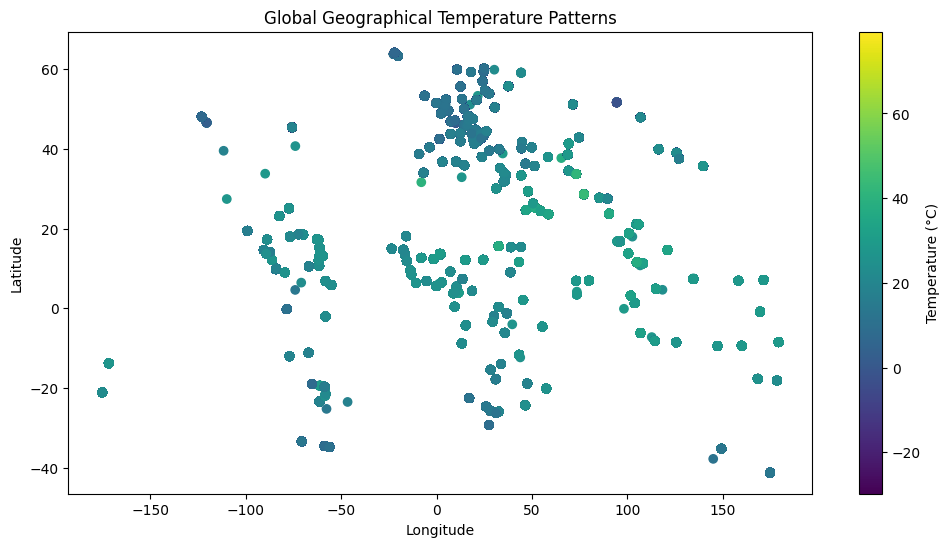

In [192]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['temperature_celsius']
)

plt.colorbar(scatter, label='Temperature (°C)')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Global Geographical Temperature Patterns')

plt.show()